# K-Means Clustering

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [29]:
# Load the dataset and prepare numeric features for clustering
df = pd.read_csv('finalclusteringdataset.csv')
print(df.head())
print('Original shape:', df.shape)
X=df[['trip_frequency','average_booking_value','destination_diversity','session_duration','search_behavior']]

   trip_frequency  average_booking_value  destination_diversity  \
0       -0.932410              -0.670922               0.799784   
1       -0.464474               0.027663               0.799784   
2       -0.464474              -0.506637              -1.186431   
3        0.003461              -0.404627              -1.186431   
4       -0.464474              -0.250067               0.799784   

   session_duration  search_behavior  
0          0.238273        -1.231300  
1         -0.216633         1.220781  
2         -0.460439        -0.005260  
3         -1.011564         1.220781  
4          0.550754        -0.005260  
Original shape: (100002, 5)


In [ ]:
# Elbow method to find optimal number of clusters (robust silhouette computation)
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_tmp.fit(X)
    wcss.append(kmeans_tmp.inertia_)
    # Compute silhouette score when possible; otherwise record NaN
    try:
        s = silhouette_score(X, kmeans_tmp.labels_)
    except Exception:
        s = np.nan
    silhouette_scores.append(s)

# Plot elbow curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:

# Compute optimal k using hybrid approach
from kneed import KneeLocator

# Step 1: k with maximum silhouette score
k_silhouette = k_range[np.nanargmax(silhouette_scores)]

# Step 2: k from elbow method
kl = KneeLocator(k_range, wcss, curve="convex", direction="decreasing")
k_elbow = kl.elbow

# Step 3: Pick optimal k (hybrid)
if k_elbow is not None:
    silhouette_at_k_elbow = silhouette_scores[k_range.index(k_elbow)]
    if not np.isnan(silhouette_at_k_elbow) and silhouette_at_k_elbow > 0.25:
        optimal_k = k_elbow 
    else:
        optimal_k = k_silhouette 
else:
    optimal_k = k_silhouette  
print("Optimal number of clusters:", optimal_k)
print(f'Optimal K: {optimal_k}')
print(f'Silhouette Score: {silhouette_scores[k_range.index(optimal_k)]:.4f}')


ModuleNotFoundError: No module named 'kneed'

In [ ]:

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

Optimal K: 5
Silhouette Score: 0.1627
Davies-Bouldin Score: 1.5623


c:\Users\vansh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


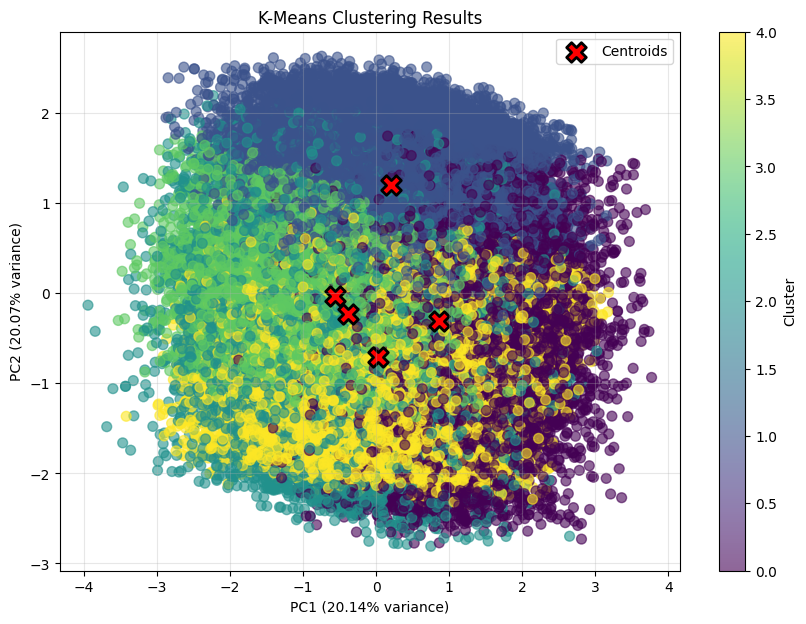

In [ ]:
# Visualize clusters (2D projection)
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=50, alpha=0.6)
# Project cluster centers into PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=200, edgecolors='black', linewidth=2, label='Centroids')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('K-Means Clustering Results')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

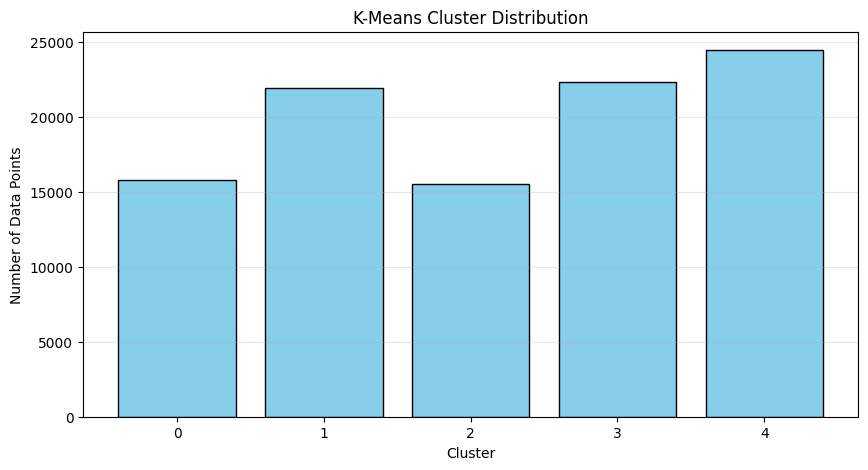

Cluster Distribution:
Cluster 0: 15798 samples (15.80%)
Cluster 1: 21897 samples (21.90%)
Cluster 2: 15534 samples (15.53%)
Cluster 3: 22335 samples (22.33%)
Cluster 4: 24438 samples (24.44%)


In [ ]:
# Cluster distribution
unique, counts = np.unique(cluster_labels, return_counts=True)
plt.figure(figsize=(10, 5))
plt.bar(unique, counts, color='skyblue', edgecolor='black')
plt.xlabel('Cluster')
plt.ylabel('Number of Data Points')
plt.title('K-Means Cluster Distribution')
plt.xticks(unique)
plt.grid(axis='y', alpha=0.3)
plt.show()

print('Cluster Distribution:')
for cluster, count in zip(unique, counts):
    print(f'Cluster {cluster}: {count} samples ({count/len(X)*100:.2f}%)')

In [ ]:
# Save results: attach cluster labels back to the original dataframe (preserving dropped rows)
df_result = df.copy()
# Initialize Cluster column and then set for rows used in clustering
df_result['Cluster'] = np.nan
df_result.loc[X.index, 'Cluster'] = cluster_labels
df_result.to_csv('kmeansresults.csv', index=False)
print('Saved results to kmeansresults.csv')

# Print accuracy if ground truth exists
if 'label' in df_result.columns:
    # Only compare rows used in clustering
    true_labels = df_result.loc[X.index, 'label']
    pred_labels = cluster_labels
    from sklearn.metrics import accuracy_score
    # Accuracy for clustering: best matching (Hungarian algorithm)
    from sklearn.utils.linear_assignment_ import linear_assignment
    import numpy as np
    def cluster_accuracy(true, pred):
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(true, pred)
        indexes = linear_assignment(-cm)
        return sum([cm[i, j] for i, j in indexes]) / len(true)
    acc = cluster_accuracy(true_labels, pred_labels)
    print(f'Clustering Accuracy: {acc:.4f}')
else:
    print('No ground truth labels found for accuracy calculation.')

Saved results to kmeansresults.csv
No ground truth labels found for accuracy calculation.
